In [1]:
from pha_lib import io, pipeline, export

In [2]:
discharge = io.load_united_txt("data\\test\\modified\\unitedc_62_239.txt")

Channel 2: detected 4 injections


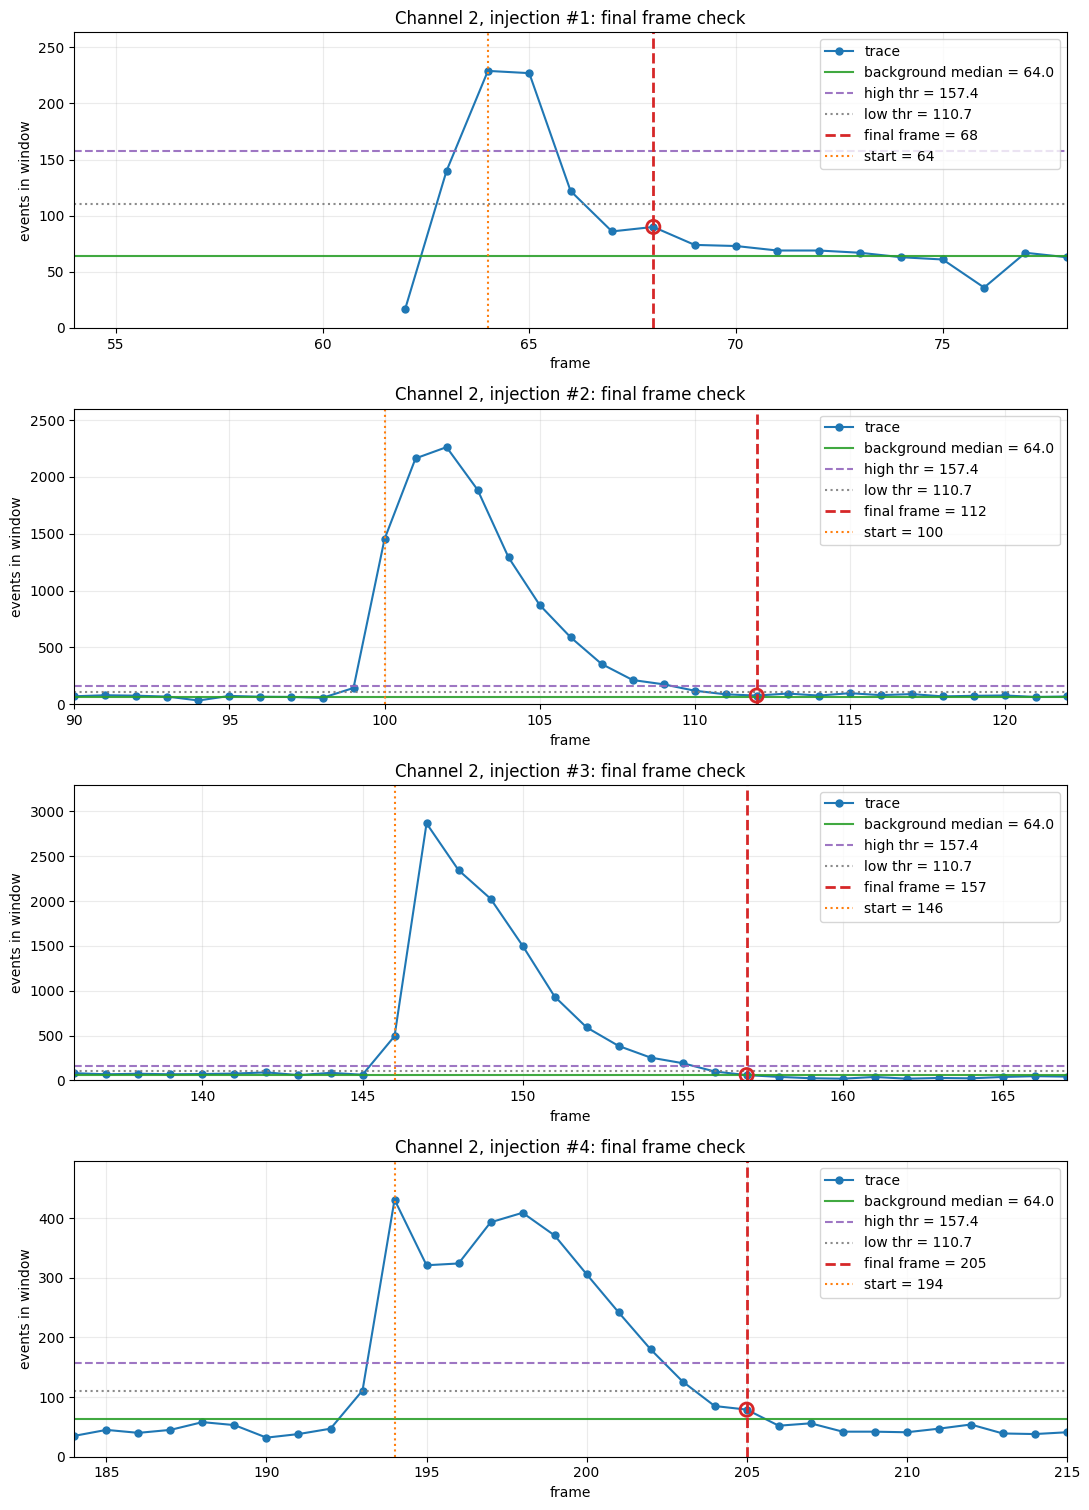

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from pha_lib.timetrace import integrate_energy_window
from pha_lib.discharges import detect_injections

channel_id = 2
line_energy_eV = 6660.0
half_width_eV = 60.0
context_pad = 7

channel = discharge.channels[channel_id]
trace = integrate_energy_window(channel, line_energy_eV, half_width_eV)
injections = detect_injections(trace, line_energy_eV)
bg = float(np.median(trace.values))
mad = float(np.median(np.abs(trace.values - bg)))
scale = max(1.4826 * mad, 1.0)
high_thr = bg + 3.0 * scale
low_thr = bg + 1.5 * scale

print(f"Channel {channel_id}: detected {len(injections)} injections")

fig, axes = plt.subplots(len(injections), 1, figsize=(11, 3.8 * len(injections)), squeeze=False)
axes = list(axes.flat)

for ax, inj in zip(axes, injections):
    lo = inj.start_frame - context_pad
    #lo = max(int(trace.frame_numbers[0]), inj.start_frame - context_pad-50)
    hi = inj.finish_frame + context_pad
    #hi = min(int(trace.frame_numbers[-1]), inj.finish_frame + context_pad)
    mask = (trace.frame_numbers >= lo) & (trace.frame_numbers <= hi)

    ax.plot(trace.frame_numbers[mask], trace.values[mask], "o-", ms=5, lw=1.5, color="tab:blue", label="trace")
    ax.axhline(bg, color="tab:green", ls="-", lw=1.5, alpha=0.9, label=f"background median = {bg:.1f}")
    ax.axhline(high_thr, color="tab:purple", ls="--", lw=1.5, alpha=0.9, label=f"high thr = {high_thr:.1f}")
    ax.axhline(low_thr, color="tab:gray", ls=":", lw=1.5, alpha=0.9, label=f"low thr = {low_thr:.1f}")
    ax.axvline(inj.finish_frame, color="tab:red", ls="--", lw=2, label=f"final frame = {inj.finish_frame}")
    ax.axvline(inj.start_frame, color="tab:orange", ls=":", lw=1.5, label=f"start = {inj.start_frame}")
    final_idx = int((trace.frame_numbers == inj.finish_frame).nonzero()[0][0])
    ax.scatter([inj.finish_frame], [trace.values[final_idx]], s=90, facecolors="none", edgecolors="tab:red", linewidths=2, zorder=5)
    ax.set_xlim(lo, hi)
    ax.set_ylim(0.0, max(trace.values[mask]) * 1.15)
    ax.set_title(f"Channel {channel_id}, injection #{inj.injection_no}: final frame check")
    ax.set_xlabel("frame")
    ax.set_ylabel("events in window")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

fig.tight_layout()
plt.show()

In [4]:
results = pipeline.analyze_shot(discharge, line_energy_eV=6660.0)

D:\ℱ Sci\IFPiLM\1st task\pha_lib\fit.py:84: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(_model, t_data, y_data, p0=p0, maxfev=5000)


In [5]:
export.save_results_parquet(results, out_dir="output\\parquet")

{1: WindowsPath('output/parquet/results_channel1.parquet'),
 2: WindowsPath('output/parquet/results_channel2.parquet')}

In [6]:
# 3. zapisz Parquet
export.save_results_parquet(results, out_dir="output", also_csv=True)

{1: WindowsPath('output/results_channel1.parquet'),
 2: WindowsPath('output/results_channel2.parquet')}